<a href="https://colab.research.google.com/github/yyred-max/Analisis_Data_Eksploratif/blob/main/Tugas12_Yuliana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/PacktPublishing/hands-on-exploratory-data-analysis-with-python/master/Chapter%209/Boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [ ]:
x = df[['CRIM', 'NOX','TAX','CHAS']]
y = df[['MEDV']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 10)

In [ ]:
regressor = LinearRegression()
regressor.fit(x_train, y_train)
print(regressor.coef_)
print(regressor.intercept_)

[[-1.49312094e-01 -1.98213937e+01 -1.16243891e-02  5.83335071e+00]]
[38.04489873]


In [ ]:
regressor.score(x_test, y_test)

0.254574440425392

In [ ]:
y_pred=regressor.predict(x_test)
evaluate = pd.DataFrame({'Actual': y_test.values.flatten(),
                         'Predicted': y_pred.flatten()})
evaluate.head(10)

,Actual,Predicted
0,28.4,26.100406
1,31.1,27.012791
2,23.5,26.233214
3,26.6,25.643022
4,19.6,15.872417
5,14.3,15.337081
6,50.0,21.149829
7,14.3,20.464910
8,20.7,32.075349
9,37.6,24.429171


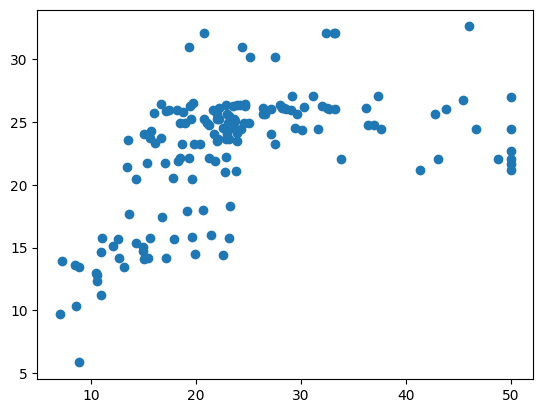

In [ ]:
prediction = regressor.predict(x_test)
plt.scatter(y_test, prediction)

<Axes: >

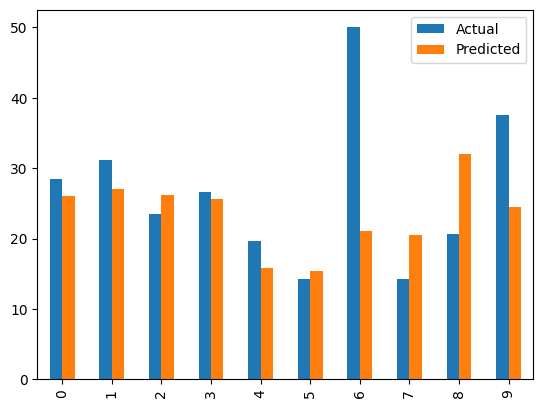

In [ ]:
evaluate.head(10).plot(kind = 'bar')

<Axes: >

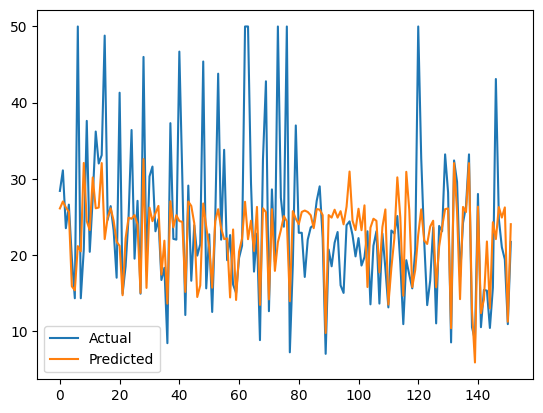

In [ ]:
evaluate.plot(kind = 'line')

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print(f"R2 score: {r2_score(y_test, prediction)}")
print(f"MAE score: {mean_absolute_error(y_test, prediction)}")
print(f"MSE score: {mean_squared_error(y_test, prediction)}")

R2 score: 0.254574440425392
MAE score: 5.695724267819929
MSE score: 72.77848236637256


In [ ]:
from sklearn.metrics import mean_squared_error

mape = np.mean(np.abs((y_test.values.flatten() - prediction)/y_test.values.flatten()))*100
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
print("MAPE :", mape)
print("RMSE: ", rmse)

MAPE : 41.2414787883968
RMSE:  8.531030557111642


In [ ]:
mae_manual = np.mean(np.abs(y_test.values.flatten() - prediction))
mse_manual = np.mean((y_test.values.flatten() - prediction)**2)
mape_manual = np.mean(np.abs((y_test - prediction) / y_test)) * 100
rmse_manual = np.sqrt(mse_manual)

print(f"MAE  : {mae_manual:.4f}")
print(f"MSE  : {mse_manual:.4f}")
print(f"MAPE : {mape_manual:.2f}%")
print(f"RMSE : {rmse_manual:.4f}")

MAE  : 8.5182
MSE  : 124.8255
MAPE : 23.15%
RMSE : 11.1725
